In [2]:
from src.Elements import Elements
from torchview import draw_graph
import graphviz 
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:

class VisionTransformer(nn.Module):
    def __init__(self, input_size, patch_size, embed_dim, num_heads, num_classes, num_layers, hidden_dim, dropout_rate):
        super(VisionTransformer, self).__init__()
        num_patches = input_size // patch_size
        self.patch_embed = nn.Conv1d(1, embed_dim, kernel_size=patch_size, stride=patch_size, bias=False)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.dropout = nn.Dropout(dropout_rate)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, hidden_dim, dropout_rate) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.fc = nn.Linear(embed_dim * num_patches, num_classes)
        self.gelu = nn.GELU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.dropout(x + self.pos_embed)
        for i, block in enumerate(self.transformer_blocks):
            x = block(x)
        x = self.norm(x)
        x = x.reshape(x.size(0), -1)

        x = self.fc(x)
        x = self.sigmoid(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, hidden_dim, dropout_rate):
        super(TransformerBlock, self).__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attention = nn.MultiheadAttention(embed_dim, num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.feedforward = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        global attention_weights
        attn_output, attn_weights = self.attention(*([self.norm1(x)] * 3), need_weights=True)
        attention_weights = attn_weights
        x = x + attn_output
        x = x + self.feedforward(self.norm2(x))

        return x

input_size = 4096
patch_size = 16
embed_dim = 16 
num_heads = 4
num_classes = len(Elements.LINES) 
num_layers = 6
hidden_dim = 4 * embed_dim
dropout_rate = 0.1

model = VisionTransformer(input_size, patch_size, embed_dim, num_heads, num_classes, num_layers, hidden_dim, dropout_rate).to(device)

model.to(device)

# model = XRFAutoencoder(latent_dim=len(Elements.LINES)).to(device)
print(model(torch.tensor([1.0]*4096 * 64).reshape(64, 1, -1).to(device))[0].shape)
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

print(model)
# graph = draw_graph(model, input_size=(64, 1, 4096))
# graphviz.set_jupyter_format('png')


torch.Size([7])
52743
VisionTransformer(
  (patch_embed): Conv1d(1, 16, kernel_size=(16,), stride=(16,), bias=False)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
      )
      (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (feedforward): Sequential(
        (0): Linear(in_features=16, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=64, out_features=16, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=4096, out_features=7, bias=True)
  (gelu): GELU(approximate='none')
  (sigmoid): Sigmoid()
)


In [4]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/artificial/X.npy")
y = np.load("data/artificial/y.npy")
y[y>0] = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 256)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 256)


torch.Size([127])


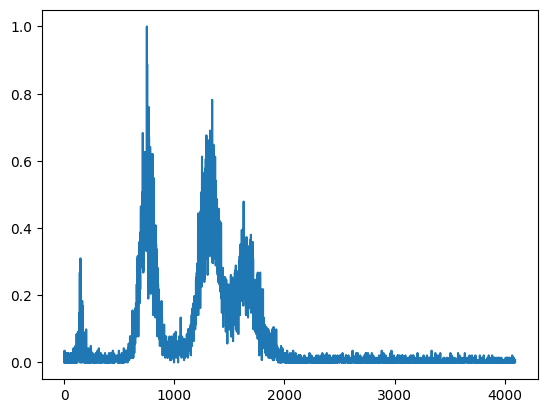

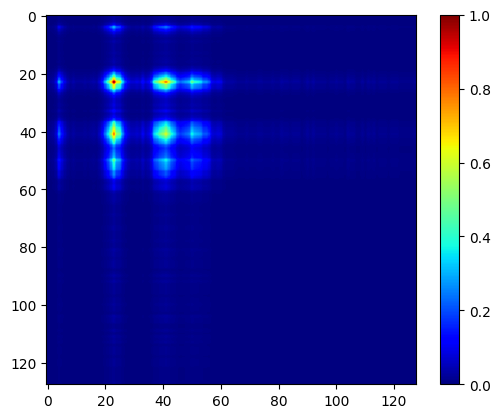

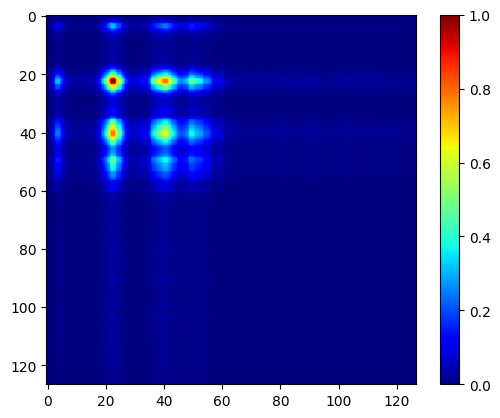

ValueError: operands could not be broadcast together with shapes (128,128) (127,127) 

<Figure size 640x480 with 0 Axes>

In [20]:
import matplotlib.pyplot as plt

def increase_contrast(image, factor=1.5):
    """
    Increases the contrast of a single-channel image.
    
    Parameters:
        image (numpy.ndarray): Input image with values in range [0, 1].
        factor (float): Contrast adjustment factor. Greater than 1 increases contrast.
    
    Returns:
        numpy.ndarray: Contrast-enhanced image, clipped to [0, 1].
    """
    mean = np.mean(image)  # Compute mean intensity
    contrasted = (image - mean) * factor + mean  # Apply contrast adjustment
    return np.clip(contrasted, 0, 1)  # Ensure values remain in [0, 1]

def downsample_average(image, factor=32):
    """
    Downsamples a single-channel image by a given factor using block averaging.

    Parameters:
        image (numpy.ndarray): Input image (H, W) with values in range [0, 1].
        factor (int): Downsampling factor.

    Returns:
        numpy.ndarray: Downsampled image.
    """
    H, W = image.shape
    H_new, W_new = H // factor, W // factor  # New size
    return image[:H_new * factor, :W_new * factor].reshape(H_new, factor, W_new, factor).max(axis=(1, 3))


plt.plot(X_train[0])

plt.figure(10)
downsampled = downsample_average(torch.tensor(X_train[0]).reshape(-1, 1).matmul(torch.tensor(X_train[0]).reshape(1, -1)).detach().cpu().numpy(), 32)
plt.imshow(downsampled, vmin=0, vmax=1, cmap="jet")
# plt.xticks(np.arange(0, 128, 4))
# plt.yticks(np.arange(0, 128, 4))
# plt.grid()
plt.colorbar()

plt.figure(15)
moving_max = torch.nn.functional.max_pool1d(torch.tensor(X_train[0]).unsqueeze(0).unsqueeze(0), kernel_size=64, stride=32).squeeze()
print(moving_max.shape)
result = torch.matmul(moving_max.unsqueeze(1), moving_max.unsqueeze(0))
plt.imshow(result, vmin=0, vmax=1, cmap="jet")
plt.colorbar()
plt.show()

plt.figure(111235)
plt.imshow(downsampled - result.detach().cpu().numpy(), cmap="jet")
plt.colorbar()
plt.show()

In [6]:
from pathlib import Path
from datetime import datetime 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# class CustomLoss(nn.Module):
#     def __init__(self, alpha=0.01):
#         super(CustomLoss, self).__init__()
#         self.alpha = alpha
#         self.mse_criterion = nn.L1Loss()
#         self.bce_criterion = nn.BCELoss()

#     def forward(self, y_pred, x_pred , y_batch, X_batch):
#         x_loss = self.mse_criterion(x_pred, X_batch) * (1 - self.alpha) 
#         y_batch[y_batch > 0] = 1
#         y_loss = self.bce_criterion(y_pred, y_batch) * self.alpha
#         return y_loss + x_loss, x_loss, y_loss
        
# custom_criterion = CustomLoss(0.5)


# train_history, valid_history, best_loss, best_weights = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=custom_criterion, epochs=300, mode="constrained_autoencoder", patience=25)

criterion = nn.MSELoss()
train_history, valid_history, best_loss, best_weights, f1_scores, accuracies, recalls, precisions = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=criterion, epochs=5, mode="supervised", patience=5)


2025-03-09 14:21:50,175 - Epoch 1/5 started.
2025-03-09 14:22:11,262 - Train Epoch Average Loss: 0.0580
2025-03-09 14:22:12,144 - Validation Loss: 0.0168
2025-03-09 14:22:12,199 - 
Accuracy       : [=====================    ] 0.8792
Precision      : [======================== ] 0.9945
Recall         : [=======================  ] 0.9600
F1 Score       : [======================== ] 0.9722
2025-03-09 14:22:12,205 - New best model saved.
2025-03-09 14:22:12,205 - Epoch 1 finished in 22.03 seconds.

2025-03-09 14:22:12,206 - Epoch 2/5 started.
2025-03-09 14:22:32,767 - Train Epoch Average Loss: 0.0173
2025-03-09 14:22:33,632 - Validation Loss: 0.0147
2025-03-09 14:22:33,687 - 
Accuracy       : [=====================    ] 0.8794
Precision      : [======================== ] 0.9983
Recall         : [=======================  ] 0.9565
F1 Score       : [======================== ] 0.9721
2025-03-09 14:22:33,693 - New best model saved.
2025-03-09 14:22:33,693 - Epoch 2 finished in 21.49 seconds.

20

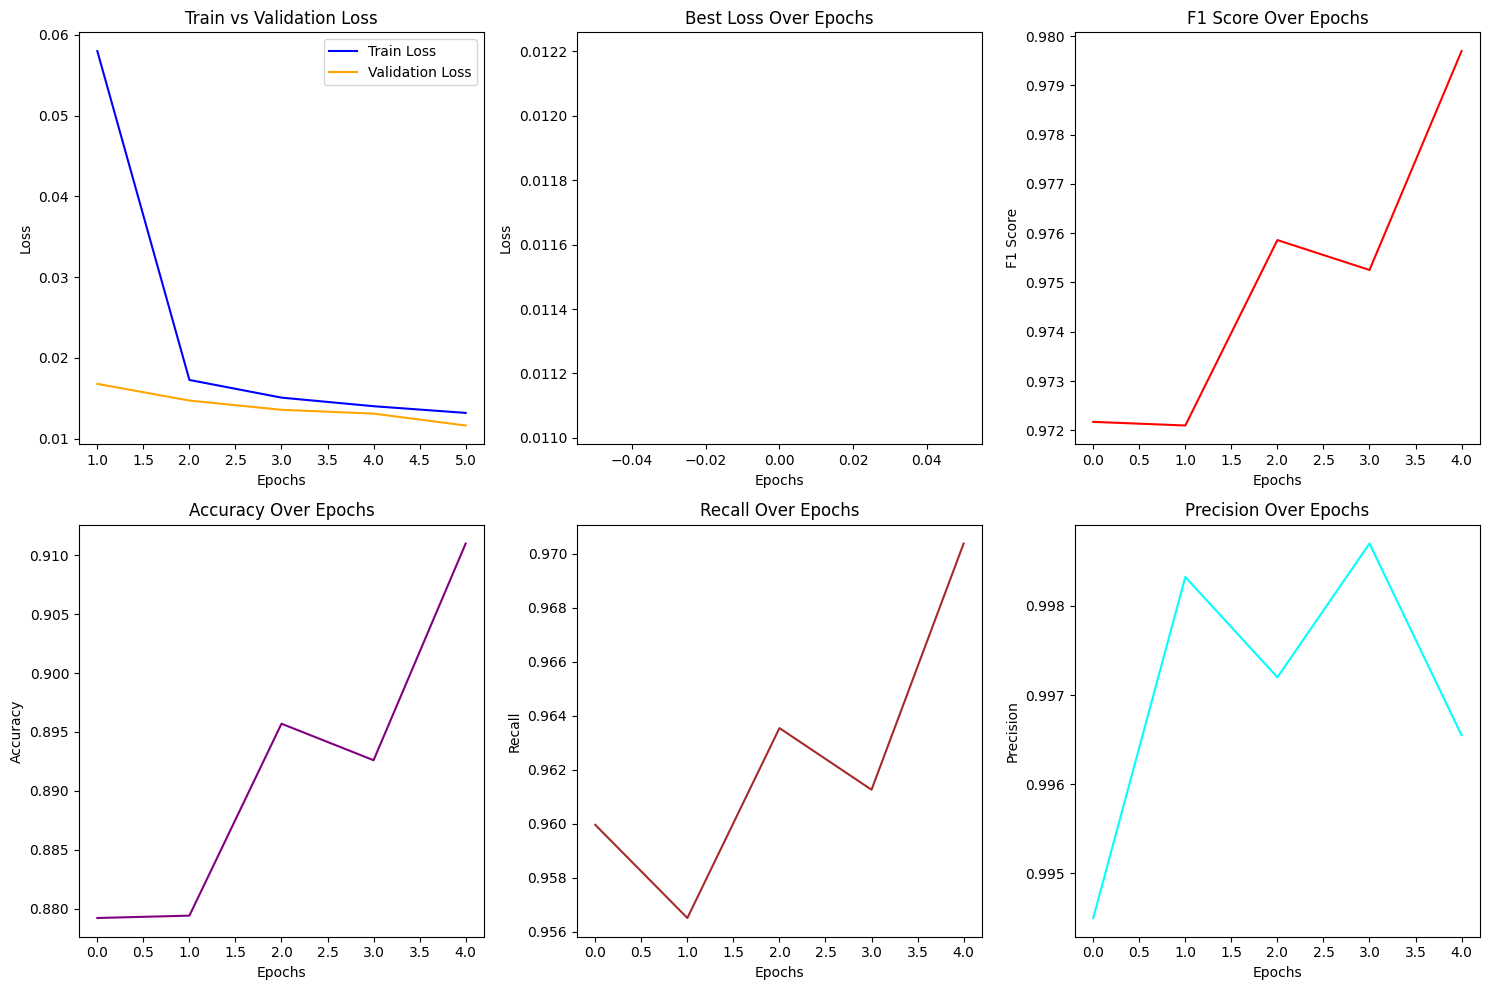

In [7]:
# Assuming these are lists or arrays representing the values over epochs
epochs = range(1, len(train_history) + 1)  # Assuming length of train_history gives number of epochs

# Create a figure and axes to hold subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Plot Train and Validation Loss
axs[0, 0].plot(epochs, train_history, label="Train Loss", color="blue")
axs[0, 0].plot(epochs, valid_history, label="Validation Loss", color="orange")
axs[0, 0].set_title("Train vs Validation Loss")
axs[0, 0].set_xlabel("Epochs")
axs[0, 0].set_ylabel("Loss")
axs[0, 0].legend()

# Plot Best Loss
axs[0, 1].plot(best_loss, label="Best Loss", color="green")
axs[0, 1].set_title("Best Loss Over Epochs")
axs[0, 1].set_xlabel("Epochs")
axs[0, 1].set_ylabel("Loss")

# Plot F1 Scores
axs[0, 2].plot(f1_scores, label="F1 Score", color="red")
axs[0, 2].set_title("F1 Score Over Epochs")
axs[0, 2].set_xlabel("Epochs")
axs[0, 2].set_ylabel("F1 Score")

# Plot Accuracy
axs[1, 0].plot(accuracies, label="Accuracy", color="purple")
axs[1, 0].set_title("Accuracy Over Epochs")
axs[1, 0].set_xlabel("Epochs")
axs[1, 0].set_ylabel("Accuracy")

# Plot Recall
axs[1, 1].plot(recalls, label="Recall", color="brown")
axs[1, 1].set_title("Recall Over Epochs")
axs[1, 1].set_xlabel("Epochs")
axs[1, 1].set_ylabel("Recall")

# Plot Precision
axs[1, 2].plot(precisions, label="Precision", color="cyan")
axs[1, 2].set_title("Precision Over Epochs")
axs[1, 2].set_xlabel("Epochs")
axs[1, 2].set_ylabel("Precision")

# Adjust layout to avoid overlapping
plt.tight_layout()
plt.show()


In [8]:
MODEL_NAME = "TRANSFORMER"
torch.save(model.state_dict(), Path(f"weights/{MODEL_NAME}--{datetime.now().strftime("%Y-%m-%d--%H-%M-%S")}"))

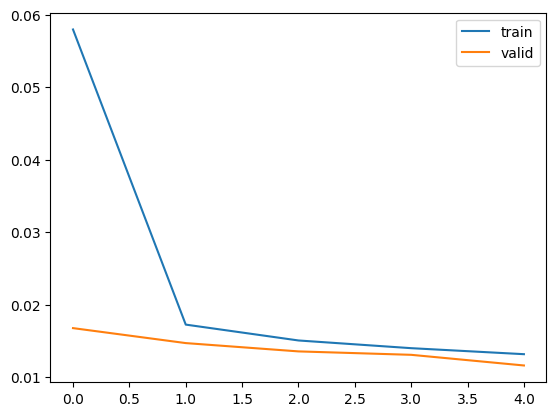

In [9]:
import matplotlib.pyplot as plt
plt.plot(train_history, label="train")
plt.plot(valid_history, label="valid")
plt.legend()


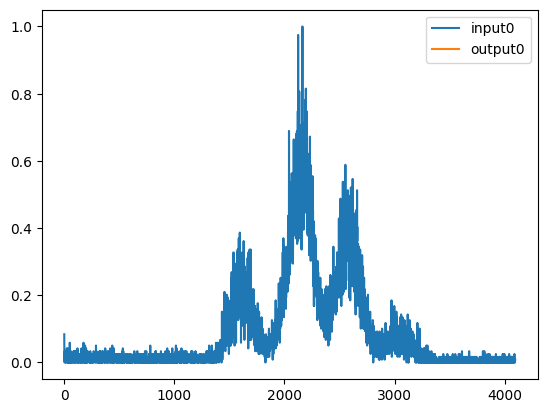

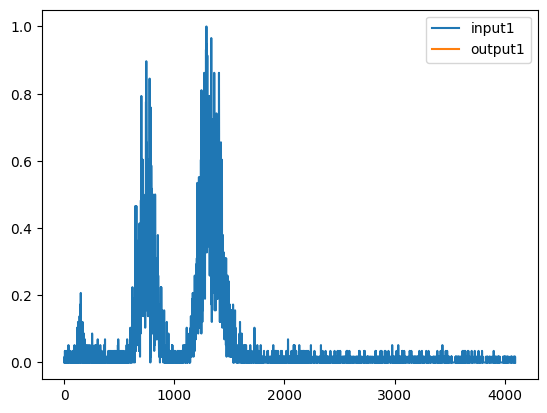

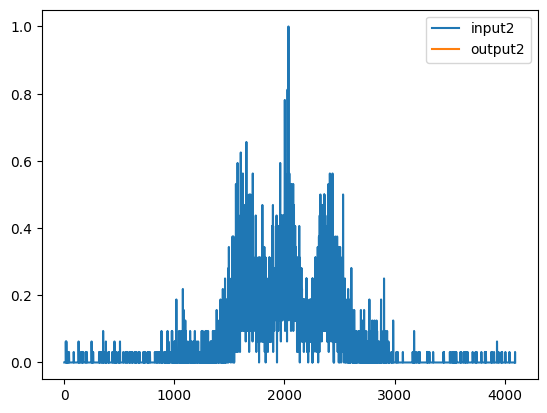

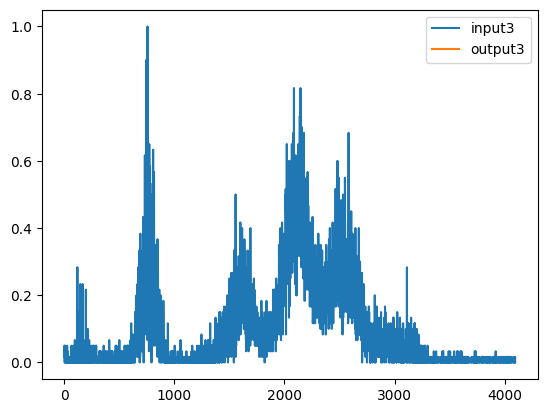

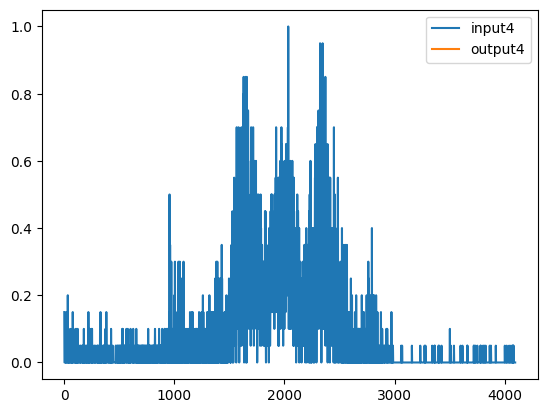

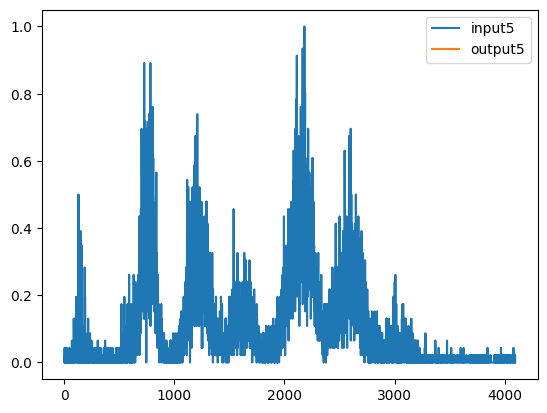

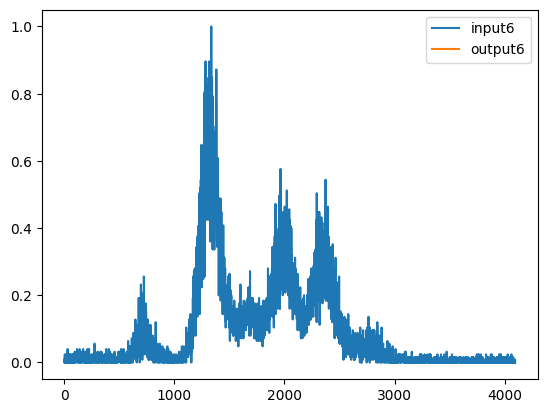

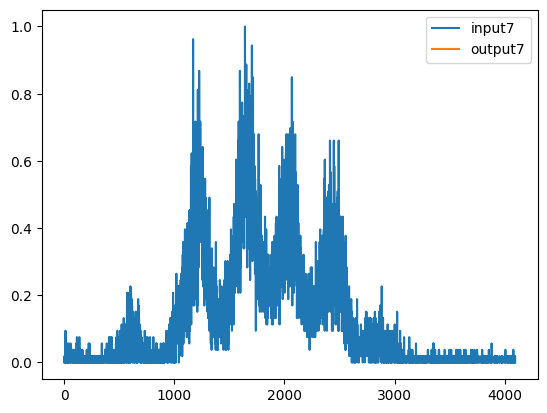

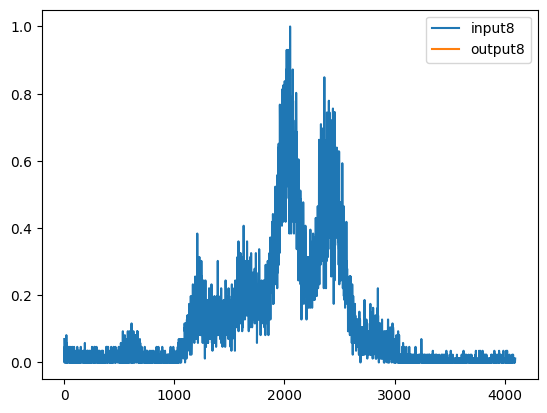

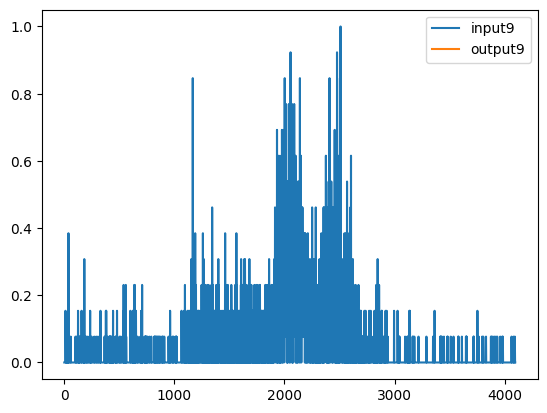

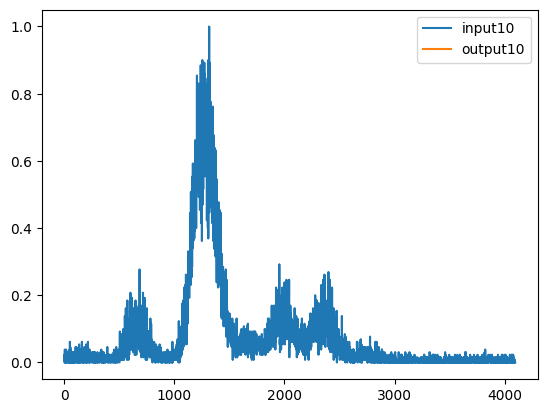

In [10]:
import matplotlib.pyplot as plt

for i, (X_batch, y_batch) in enumerate(trainloader):
    X_true, y_true = X_batch.cpu().squeeze().detach().numpy()[0], y_batch.cpu().squeeze().detach().numpy()[0]
    X_pred, y_pred = model(X_batch)[0].cpu().squeeze().detach().numpy()[0], model(X_batch)[1].cpu().squeeze().detach().numpy()[0]

    plt.figure(i)
    plt.plot(X_true, label=f"input{i}")
    plt.plot(X_pred, label=f"output{i}")
    plt.legend()
    if i == 10:
        break